# Covid Research
## Is there a link between the number of deaths and the GDP of a country?
Our hypothesis: The GDP will have a negative correlation on the total number of deaths for a country.
### 1. Importing the data
Datasets:
1. https://github.com/datasets/gdp
2. https://github.com/owid/covid-19-data/tree/master/public/data

In [44]:
import pandas as pd

covid_df = pd.read_csv('datasets/owid-covid-data.csv')
gdp_df = pd.read_csv('datasets/gdp_years_country.csv')

### 2. Exploring the data

In [45]:
# Description of the columns and their datatypes
print('Description of the covid-19 dataset')
print(covid_df.describe())
print(covid_df.columns)

print('Description of the GDP dataset')
print(gdp_df.describe())
print(gdp_df.columns)

# let's look at what's in the dataset
print('head of the covid-19 dataset')
print(covid_df.head())

print('Head of the GDP dataset')
print(gdp_df.head())

Description of the covid-19 dataset
        total_cases      new_cases  new_cases_smoothed  total_deaths  \
count  1.088530e+05  108850.000000       107835.000000  9.827600e+04   
mean   1.311159e+06    6384.869049         6386.860757  3.393430e+04   
std    8.829509e+06   39188.437733        38686.482710  2.024379e+05   
min    1.000000e+00  -74347.000000        -6223.000000  1.000000e+00   
25%    1.750000e+03       2.000000            8.571000  6.300000e+01   
50%    1.777400e+04      86.000000          106.857000  5.350000e+02   
75%    1.904990e+05     889.000000          938.857000  4.653000e+03   
max    2.198214e+08  905932.000000       826340.429000  4.553701e+06   

         new_deaths  new_deaths_smoothed  total_cases_per_million  \
count  98430.000000        107835.000000            108278.000000   
mean     146.201880           132.548782             16143.344814   
std      797.706504           744.015456             28194.834522   
min    -1918.000000          -232.14300

### 3. Filter the data
Let's filter out the data and create a new dataset containing all the COVID-19 deaths and cases for a specific country with the GDP of the respective country
Luckily we obtained a dataset where the countries are represented as an ISO code

In [46]:
covid_per_country_df_filtered = covid_df.groupby('iso_code').agg({
    'total_cases': 'max',
    'total_deaths': 'max'
}).dropna()

country_gdp_df = gdp_df[['Country Code', '2020']]

covid_per_country_with_gdp_df = pd.merge(covid_per_country_df_filtered, country_gdp_df.rename(columns={'Country Code':'iso_code', '2020':'gdp'}),
         on='iso_code', how='right').dropna().reset_index(drop=True)

# Describe the new DataFrame
print(covid_per_country_with_gdp_df.describe())
print(covid_per_country_with_gdp_df.head())

        total_cases   total_deaths           gdp
count  1.690000e+02     169.000000  1.690000e+02
mean   1.274021e+06   26689.130178  4.581919e+11
std    4.403228e+06   82041.210435  2.012566e+12
min    4.000000e+00       1.000000  4.698704e+08
25%    2.198000e+04     363.000000  1.196185e+10
50%    1.650510e+05    2837.000000  3.737203e+10
75%    6.700270e+05   12923.000000  2.487156e+11
max    3.985026e+07  647579.000000  2.093660e+13
  iso_code  total_cases  total_deaths           gdp
0      AFG     153375.0        7127.0  1.980707e+10
1      AGO      48261.0        1248.0  6.230691e+10
2      ALB     149117.0        2508.0  1.479962e+10
3      ARG    5199919.0      112356.0  3.830670e+11
4      ARM     243981.0        4892.0  1.264546e+10


### 4. Time to start working on the analysis

              total_cases  total_deaths       gdp
total_cases      1.000000      0.929675  0.648304
total_deaths     0.929675      1.000000  0.580472
gdp              0.648304      0.580472  1.000000


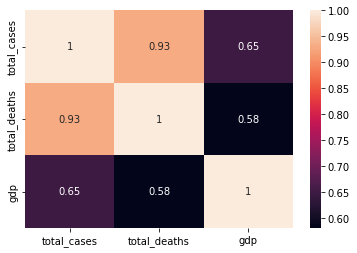

In [47]:
# Let's determine the correlation

correlation = covid_per_country_with_gdp_df.corr()
print(correlation)

# So now I want two things:
# 1. The correlation between the GDP and the total no. of cases
# 2. The correlation between the GDP and the total no. of deaths
gdp = covid_per_country_with_gdp_df['gdp']
cases = covid_per_country_with_gdp_df['total_cases']
deaths = covid_per_country_with_gdp_df['total_deaths']

# Let's visualize it right now!
import seaborn as sns

# Correlation plot GDP - Cases
heatmap_vis = sns.heatmap(correlation, annot=True)

We might be inclined to say that we have a positive correlation (>0.6) *but*, I'd like to dig deeper.
Let's take a sample of the data.

I would like to order the data based on the number of cases and take the median.
We will compare the data beneath the 50% percentile (Q2) and above and see if there is an effect on the correlation.

In [48]:
# Let's order the data on the GDP
covid_per_country_with_gdp_df = covid_per_country_with_gdp_df.sort_values(by='gdp')
number_of_rows = len(covid_per_country_with_gdp_df)
midpoint = number_of_rows // 2
above_median = covid_per_country_with_gdp_df.iloc[midpoint:number_of_rows]
below_median = covid_per_country_with_gdp_df.iloc[0:midpoint]

assert len(below_median) + len(above_median) == len(covid_per_country_with_gdp_df)

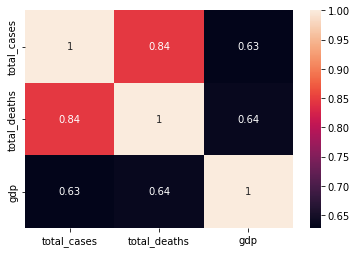

In [49]:
# Now, redo the correlation
heatmap_below_median = sns.heatmap(below_median.corr(), annot=True)

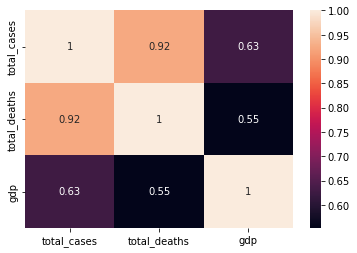

In [50]:
heatmap_above_median = sns.heatmap(above_median.corr(), annot=True)
